*Use this notebook to complete the sentence similarity and embedding visualization tasks.*


In [61]:

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
import pickle
import gensim
import numpy as np
from gensim.models import KeyedVectors
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap



[nltk_data] Downloading package punkt to
[nltk_data]     /Users/camelliazhou/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [62]:
#Sentence Similarity

def tokenize_text(text):
    return word_tokenize(text.lower())

#cosine similarity formulation:
def cosine_sim(u, v, eps=1e-12):
    denominator = (np.linalg.norm(u) * np.linalg.norm(v)) + eps
    return float(np.dot(u, v) / denominator)

def sentence_embedding(tokens, get_vec, dim):
    vector = []
    for w in tokens:
        v = get_vec(w)
        if v is not None:
            vector.append(v)
    if len(vector) == 0:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(np.stack(vector), axis=0)


#word2vec_embeddings.pkl
def load_pytorch_pkl(path="word2vec_embeddings.pkl"):
    with open(path, "rb") as f:
        data = pickle.load(f)
    embedding = data["embeddings"]            
    word2idx = data["word2idx"]
    dim = embedding.shape[1]

    def get_vec(word):
        idx = word2idx.get(word, None)
        if idx is None:
            return None
        return embedding[idx]
    return get_vec, dim


#word2vec_gensim_embeddings
def load_gensim_pkl(path="word2vec_gensim_embeddings.pkl"):
    with open(path, "rb") as f:
        data = pickle.load(f)
    embedding = data["embeddings"]
    word2idx = data["word2idx"]
    dim = embedding.shape[1]

    def get_vec(word):
        idx = word2idx.get(word, None)
        if idx is None:
            return None
        return embedding[idx]
    return get_vec, dim

get_vec_gensim_text8, dim_gensim_text8 = load_gensim_pkl("word2vec_gensim_embeddings.pkl")


#word2vec-google-news-300.model
google_model = gensim.models.KeyedVectors.load("word2vec-google-news-300.model")
dim_google = google_model.vector_size

def get_vec_google(word):
    if word in google_model.key_to_index:
        return google_model.get_vector(word)
    return None

#fasttext-wiki-news-subwords-300.model
fast_wv = KeyedVectors.load("fasttext-wiki-news-subwords-300.model")
dim_fast = fast_wv.vector_size

def get_vec_fasttext(word):
    try:
        return fast_wv.get_vector(word)
    except KeyError:
        return None

# List of sentences for comparison
sentences = [
    "The cat sat on the mat.",
    "A dog is playing in the yard.",
    "I need to buy groceries today.",
    "The feline was resting on the rug.",
    "Canines enjoy outdoor activities.",
    "My shopping list includes milk and bread.",
    "The weather is beautiful today.",
    "Programming requires logical thinking."
]

# Query sentence
query = "My pet cat is sleeping on the carpet."

def similarity_score(name, get_vec, dim):
    query_tokens = tokenize_text(query)
    query_vec = sentence_embedding(query_tokens, get_vec, dim)

    results = []
    for sentence in sentences:
        sentence_tokens = tokenize_text(sentence)
        sentence_vec = sentence_embedding(sentence_tokens, get_vec, dim)
        similarity = cosine_sim(query_vec, sentence_vec)
        results.append((similarity, sentence))
    results.sort(reverse=True, key=lambda x: x[0])
    print(f"\n{name}:")
    for similarity, sentence in results:
        print(f"{similarity} | {sentence}")

similarity_score("PyTorch Skip-Gram (100d)", get_vec_pytorch, dim_pytorch)
similarity_score("Gensim Word2Vec text8 (100d)", get_vec_gensim_text8, dim_gensim_text8)
similarity_score("Pretrained Word2Vec GoogleNews (300d)", get_vec_google, dim_google)
similarity_score("Pretrained FastText Wiki (300d)", get_vec_fasttext, dim_fast)



PyTorch Skip-Gram (100d):
0.5045433113128114 | The cat sat on the mat.
0.43529285778037896 | The feline was resting on the rug.
0.3426073089837121 | A dog is playing in the yard.
0.2442524201870227 | The weather is beautiful today.
0.09012062219096065 | My shopping list includes milk and bread.
0.05869304909078671 | Programming requires logical thinking.
-0.013220953986270314 | I need to buy groceries today.
-0.15303004609803572 | Canines enjoy outdoor activities.

Gensim Word2Vec text8 (100d):
0.694682521875661 | The cat sat on the mat.
0.5944194105654681 | A dog is playing in the yard.
0.5096613213289295 | The weather is beautiful today.
0.4894963914018863 | The feline was resting on the rug.
0.44533864008292956 | My shopping list includes milk and bread.
0.19842077427442317 | I need to buy groceries today.
0.07521490859873979 | Canines enjoy outdoor activities.
0.048280607720054894 | Programming requires logical thinking.

Pretrained Word2Vec GoogleNews (300d):
0.7793821784613851 |

1. Pytorch skip-gram: from the results, the Pytorch Skip-gram model shows the lowest sentence similarity and some are even negative. However, it still ranks the most relevant sentences correctly in the top three positions. It might because the model depends on local words co-occurrence not deeper semantic understanding. It can capture key words such as “cat” and “sleeping,” but it doesn't understand synonym relationships well, like cat and felien. The embedding dimension is 100 less than 300, which limits to represent deeper semantic information.
2. Gensim Word2vec text8: it shows a similar behavior to the Pytorch Skip-gram model, but with generally higher similarity scores. However, there is an obvious ranking problem is “The weather is beautiful today” ranking higher than “The feline was resting on the rug.” It might because model is also driven by local word co-occurrence. In text8 corpus, words such as “today,” “weather,” “cat,” and “dog” appear together often, which may lead to wrong rank. The embedding dimension is 100 less than 300, which limits to represent deeper semantic information.
3. Pretrained Word2Vec GoogleNews (300d): it captures sentence meaning more accurately with higher scores. The top 3 ranks are correct and reasonable. Because this model is trained on a large corpus and can recognize synonyms and related expressions in semantic, such as “cat” and “feline,”, “rug” and “carpet.” Also, the embedding dimension is larger than 100, which can represent deeper semantic information.
4. Pretrained FastText Wiki (300d): it is the best model from these four, which sentence meaning are  more accurately. From the results, sentences that are semantically similar to the query, such as “The feline was resting on the rug” and “The cat sat on the mat,” are ranked at the top. Since the model is trained on a very large corpus and can recognize synonyms and related expressions in semantic, such as “cat” and “feline,”, “rug” and “carpet.” Also, the embedding dimension is larger than 100, which can represent deeper semantic information. Besides that, the ablitity of this model is high subword ability, so the cosine similarity is getting the highest.


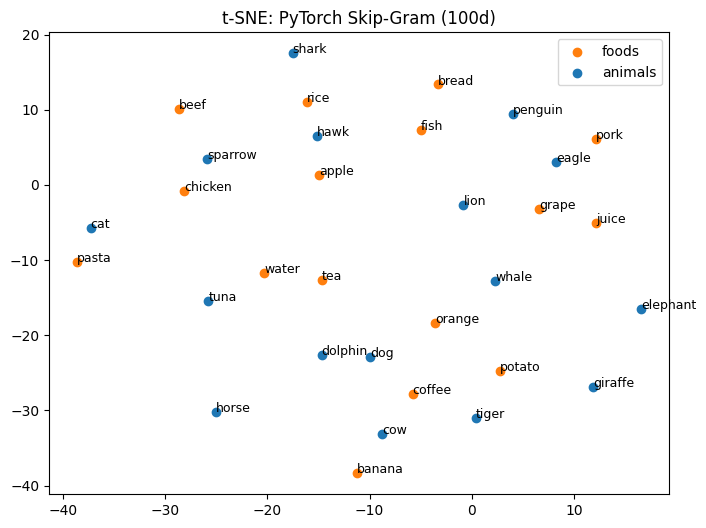

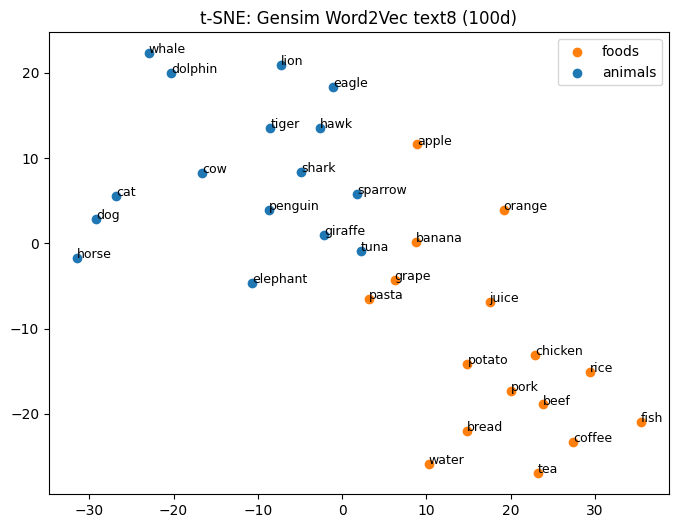

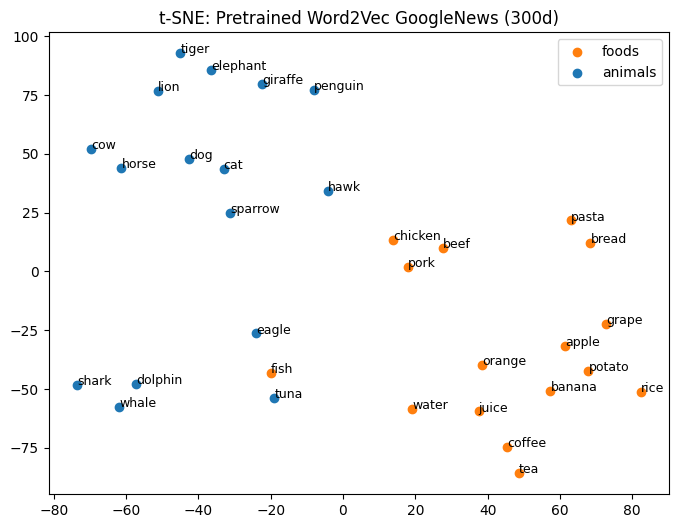

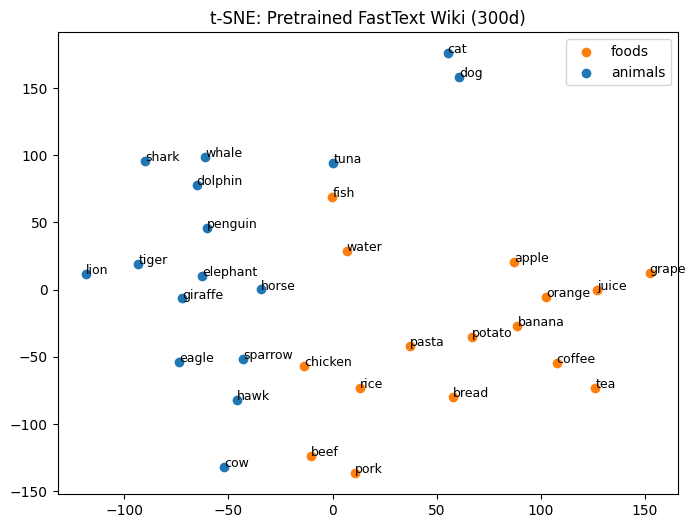

In [63]:
#Visualization
animals = [
    'dog', 'cat', 'horse', 'cow',
    'lion', 'tiger', 'elephant', 'giraffe',
    'eagle', 'hawk', 'sparrow', 'penguin',
    'shark', 'whale', 'dolphin', 'tuna'
]

foods = [
    'apple', 'orange', 'banana', 'grape',
    'bread', 'pasta', 'rice', 'potato',
    'chicken', 'beef', 'pork', 'fish',
    'coffee', 'tea', 'juice', 'water'
]


def get_vectors(words_by_group, get_vec):
    X = []
    labels = []
    for group, words in words_by_group.items():
        for w in words:
            v = get_vec(w)
            if v is None:
                continue
            X.append(v)
            labels.append(group)

    X = np.vstack(X)
    return X, labels



def plot_cluster(points, labels, words, title):
    plt.figure(figsize=(8, 6))

    color_map = {"animals": "tab:blue", "foods": "tab:orange"}

    for group in set(labels):
        idxs = [i for i, g in enumerate(labels) if g == group]
        plt.scatter(points[idxs, 0], points[idxs, 1],
                    label=group, c=color_map.get(group, "gray"))
        
        for i in idxs:
            plt.text(points[i, 0], points[i, 1],
                     words[i], fontsize=9)
    plt.title(title)
    plt.legend()
    plt.show()

    
    
def visualize_tsne(name, get_vec, dim, perplexity=5):
    groups = {"animals": animals, "foods": foods}
    X, labels, words_kept, _ = collect_vectors(groups, get_vec, dim)
    tsne = TSNE(n_components=2, perplexity=5, random_state=0)
    Z = tsne.fit_transform(X)
    plot_cluster(Z, labels, words_kept, f"t-SNE: {name}")

    
visualize_tsne("PyTorch Skip-Gram (100d)", get_vec_pytorch, dim_pytorch)
visualize_tsne("Gensim Word2Vec text8 (100d)", get_vec_gensim_text8, dim_gensim_text8)
visualize_tsne("Pretrained Word2Vec GoogleNews (300d)", get_vec_google, dim_google)
visualize_tsne("Pretrained FastText Wiki (300d)", get_vec_fasttext, dim_fast)



/Users/camelliazhou/Library/Caches/pypoetry/virtualenvs/stat359-su25--2ee_7aM-py3.12/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/camelliazhou/Library/Caches/pypoetry/virtualenvs/stat359-su25--2ee_7aM-py3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


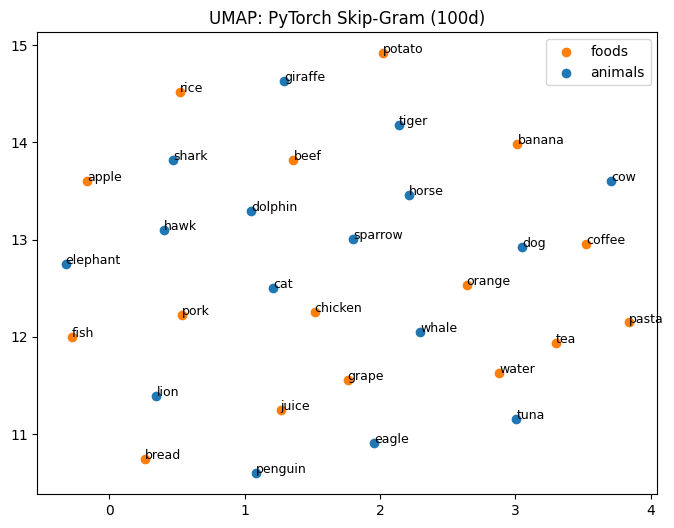

/Users/camelliazhou/Library/Caches/pypoetry/virtualenvs/stat359-su25--2ee_7aM-py3.12/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/camelliazhou/Library/Caches/pypoetry/virtualenvs/stat359-su25--2ee_7aM-py3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


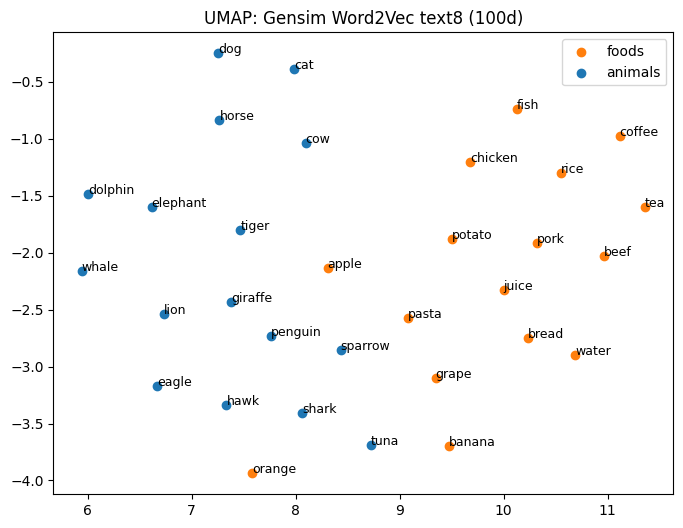

/Users/camelliazhou/Library/Caches/pypoetry/virtualenvs/stat359-su25--2ee_7aM-py3.12/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/camelliazhou/Library/Caches/pypoetry/virtualenvs/stat359-su25--2ee_7aM-py3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


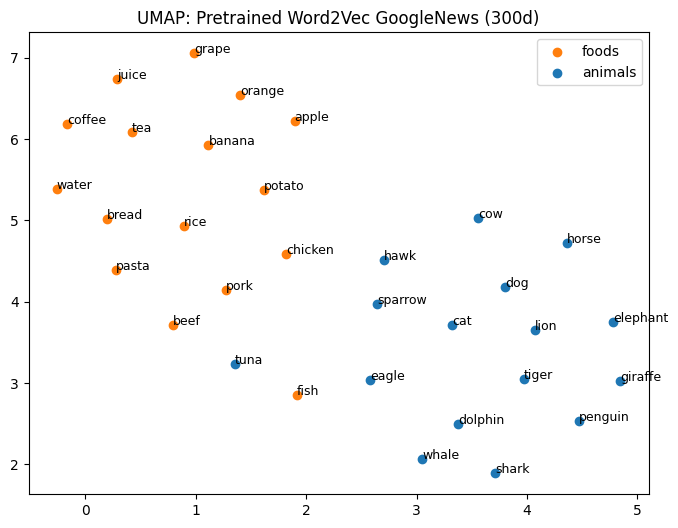

/Users/camelliazhou/Library/Caches/pypoetry/virtualenvs/stat359-su25--2ee_7aM-py3.12/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/camelliazhou/Library/Caches/pypoetry/virtualenvs/stat359-su25--2ee_7aM-py3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


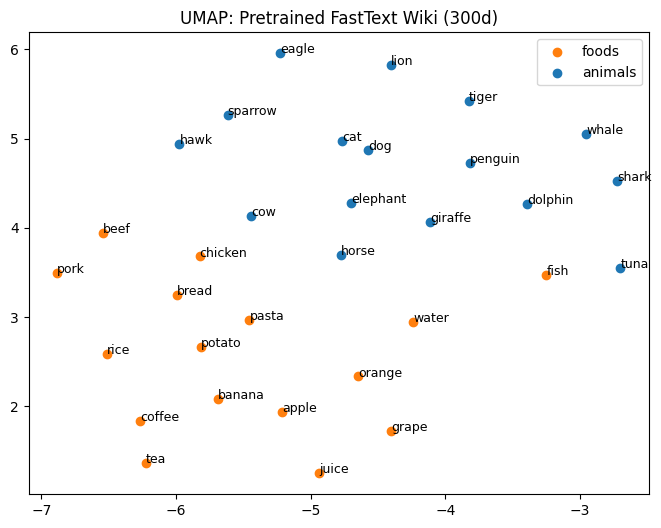

In [64]:

def visualize_umap(name, get_vec, dim, random_state=0, n_neighbors=12, min_dist=0.4):
    groups = {"animals": animals, "foods": foods}
    X, labels, words_kept, ovv = collect_vectors(groups, get_vec, dim)

    if X is None or X.shape[0] < 5:
        print("Not enough words found to plot.")
        return

    reducer = umap.UMAP(n_components=2,
        n_neighbors=min(n_neighbors, X.shape[0]-1),
        min_dist=min_dist,
        random_state=random_state)
    
    Z = reducer.fit_transform(X)
    plot_cluster(Z, labels, words_kept, f"UMAP: {name}")

#UMAP
visualize_umap("PyTorch Skip-Gram (100d)", get_vec_pytorch, dim_pytorch)
visualize_umap("Gensim Word2Vec text8 (100d)", get_vec_gensim_text8, dim_gensim_text8)
visualize_umap("Pretrained Word2Vec GoogleNews (300d)", get_vec_google, dim_google)
visualize_umap("Pretrained FastText Wiki (300d)", get_vec_fasttext, dim_fast)



1. In Pytorch Skip-gram model, the two groups are still somewhat mixed, forming a cross-over trend, and the dividing line isn't as clear as with words like "fish" and "tuna," which can be considered both animals and food.
2. In Gensim Word2vec text8 model, two independent and distinct clusters have already formed.  
3. in both pretraines models, the two groups are quite clearly distinguishable, and notably, the dividing line is separated by words that can belong to both categories: fish, chicken, and tuna.

###Short Answers:
1. Which embeddings performed best at capturing sentence meaning?
The pretrained Fasttext wiki model is best. In sentence similarity, it gets the highest similarity score and ranks correctly, 
which means it can catch semantical sentence. Moreover, it distinguish groups well.

2. Were the pretrained embeddings significantly better than your own? Why or why not?
Yes. Because my own embedding is based on local vocab and co-occurence, which doesn't catch the semantic in a whole sentence. 
While pre-trained model based on a super large corpus, it contains rich contexts and relationships, dividing the different types well.

3. What factors might explain the differences in performance?
The first is different dimensions. The more dimensions of embedding, the deeper information it can get.
The second reason is size and quality of trained dataset, pre-trained dataset is much richer and higher quality than my own.


## AI Use Disclosure (Required)

If you used any AI-enabled tools (e.g., ChatGPT, GitHub Copilot, Claude, or other LLM assistants) while working on this assignment, you must disclose that use here. The goal is transparency-not punishment.

In your disclosure, briefly include:
- **Tool(s) used:** (name + version if known)
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text)
- **What you verified yourself:** (e.g., reran the notebook, checked outputs/plots, checked shapes, read documentation)
- **What you did *not* use AI for (if applicable):** (optional)

You are responsible for the correctness of your submission, even if AI suggested code or explanations.

#### <font color="red">Write your disclosure here.</font>


1. I used chat gpt 5.2.
2. I ask it for helping explaning ptyorch_tutorial.py, explaining the concepts and framework of word2vec and debugging.
3. I check whether the results and plots are reasonable or not. 

In [ ]:
#Bonus Within & Between Bonus
def cosine_similarity(u, v, eps=1e-12):
    denom = (np.linalg.norm(u) * np.linalg.norm(v)) + eps
    return float(np.dot(u, v) / denom)

def avg_within_distance(words, get_vec):
    vecs = []
    for w in words:
        v = get_vec(w)
        if v is not None:
            vecs.append(v)

    distances = []
    for i in range(len(vecs)):
        for j in range(i + 1, len(vecs)):
            dist = 1 - cosine_sim(vecs[i], vecs[j])
            distances.append(dist)

    return np.mean(distances)

def avg_between_distance(words1, words2, get_vec):
    distances = []

    for w1 in words1:
        v1 = get_vec(w1)
        if v1 is None:
            continue
        for w2 in words2:
            v2 = get_vec(w2)
            if v2 is None:
                continue
            dist = 1 - cosine_sim(v1, v2)
            distances.append(dist)

    return np.mean(distances)

def analyze_embedding(name, get_vec):
    within_animals = avg_within_distance(animals, get_vec)
    within_foods = avg_within_distance(foods, get_vec)
    between = avg_between_distance(animals, foods, get_vec)

    print(f"\n{name}")
    print(f"Within animals distance: {within_animals}")
    print(f"Within foods distance:   {within_foods}")
    print(f"Between groups distance: {between}")


analyze_embedding("PyTorch Skip-Gram (100d)", get_vec_pytorch)
analyze_embedding("Gensim Word2Vec text8 (100d)", get_vec_gensim_text8)
analyze_embedding("Pretrained Word2Vec GoogleNews (300d)", get_vec_google)
analyze_embedding("Pretrained FastText Wiki (300d)", get_vec_fasttext)



PyTorch Skip-Gram (100d)
Within animals distance: 1.0096
Within foods distance:   1.0155
Between groups distance: 0.9958

Gensim Word2Vec text8 (100d)
Within animals distance: 0.5244
Within foods distance:   0.4144
Between groups distance: 0.6351

Pretrained Word2Vec GoogleNews (300d)
Within animals distance: 0.6492
Within foods distance:   0.6723
Between groups distance: 0.8342

Pretrained FastText Wiki (300d)
Within animals distance: 0.5350
Within foods distance:   0.5434
Between groups distance: 0.6510


1. For the Pytorch Skip-gram embeddings, the within-group distances of animals and foods and the between-group distance  are near 1, which means the embeddings don't capture meaningful semantic structure and perform randomly.

2. For the Gensim Word2Vec model, it shows smaller within-group distances and a larger between-group distance(0~1), which means it improves semantic within categories and divide two groups clearly.

3. For the pretrained Word2vec model, itshows the largest between-group distance, which means it has the strongest semantic separation between animals and foods. It also has small within-group distance to show similarity.

4. For the Fasttext embeddings, it also shows relatively small within-group distances and moderate between-group separation, reflecting stable semantic representations influenced by subword information.

I think it is a good method to reflect pre-trained model based on larger and rich corpus can capture sentence's similarity and seperate different types well.